# EKF Comparison — Baseline vs QF-EKF
**Side-by-side: raw EKF (no filter) vs QNN pre-filtered EKF**

Loads two bags simultaneously:
- `BASELINE_BAG` — recorded with `record_baseline_bag.sh`
- `HYBRID_BAG`   — recorded with `record_hybrid_bag.sh`

Both bags must cover same motion profile for fair comparison.

**Key metrics compared:**
1. XY trajectory fidelity
2. Drift rate (m/min)
3. GPS innovation RMSE
4. Velocity tracking accuracy vs cmd_vel
5. IMU noise before/after QNN filter
6. Closure error

In [33]:
# ── SET BAG PATHS ─────────────────────────────────────────────────────────────
BASELINE_BAG = '/home/rosdata/rosbags/moving_bot_baseline_test_20260420_235644'
HYBRID_BAG   = '/home/rosdata/rosbags/moving_bot_live_test_20260420_235133'
PLOT_DIR     = '/home/anish/Multi-sensor-fusion/plots/comparison'
# ─────────────────────────────────────────────────────────────────────────────

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.signal import welch, savgol_filter
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

os.makedirs(PLOT_DIR, exist_ok=True)
typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a', 'grid.alpha': 0.5,
    'legend.facecolor': '#16213e', 'legend.edgecolor': '#444444',
    'font.size': 11, 'figure.dpi': 100,
})

# Baseline = red family, QF-EKF = green/blue family
C = {
    'b_wheel':   '#ff6b6b',   # baseline wheel
    'b_ekf_l':   '#ff9f43',   # baseline EKF local
    'b_ekf_g':   '#ffd43b',   # baseline EKF global
    'q_wheel':   '#51cf66',   # QF wheel
    'q_ekf_l':   '#20c997',   # QF EKF local
    'q_ekf_g':   '#339af0',   # QF EKF global
    'imu_raw':   '#ff6b6b',
    'imu_flt':   '#51cf66',
    'gps':       '#a29bfe',
    'cmd_vel':   '#cc5de8',
}

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def npc(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def mask_finite(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs: m &= np.isfinite(a)
    return m

def noise_std(sig):
    wl = min(51, max(5, (len(sig)//5)*2+1))
    if wl % 2 == 0: wl += 1
    if len(sig) < wl: return np.std(sig)
    return np.std(sig - savgol_filter(sig, wl, 3))

print('Bag paths set.')
print(f'  Baseline: {Path(BASELINE_BAG).exists()}')
print(f'  Hybrid  : {Path(HYBRID_BAG).exists()}')

Bag paths set.
  Baseline: True
  Hybrid  : True


## 1. Extract Both Bags

In [34]:
def extract_bag(bag_path, is_hybrid=False):
    """Extract odometry, IMU, GPS, and Gazebo ground truth from a bag."""
    keys = ['wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global',
            'imu', 'gps', 'cmd_vel', 'ground_truth']
    if is_hybrid:
        keys += ['wheel_flt', 'visual_flt', 'lidar_flt', 'imu_flt']
    raw = {k: [] for k in keys}

    TOPIC_MAP = {
        '/diff_drive_controller/odom':  'wheel',
        '/odometry/visual':             'visual',
        '/odometry/lidar':              'lidar',
        '/odometry/local':              'ekf_local',
        '/odometry/global':             'ekf_global',
        '/imu/data':                    'imu',
        '/gps/fix':                     'gps',
        '/cmd_vel':                     'cmd_vel',
        '/ground_truth/odom':           'ground_truth',
    }
    if is_hybrid:
        TOPIC_MAP.update({
            '/diff_drive_controller/odom/filtered': 'wheel_flt',
            '/odometry/visual/filtered':            'visual_flt',
            '/odometry/lidar/filtered':             'lidar_flt',
            '/imu/data/filtered':                   'imu_flt',
        })

    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        for connection, timestamp, rawdata in reader.messages():
            key = TOPIC_MAP.get(connection.topic)
            if key is None or key not in raw: continue
            msg = reader.deserialize(rawdata, connection.msgtype)
            t = timestamp * 1e-9

            if key in ('wheel','visual','lidar','ekf_local','ekf_global',
                       'wheel_flt','visual_flt','lidar_flt','ground_truth'):
                raw[key].append({'t': t,
                    'x':   msg.pose.pose.position.x,
                    'y':   msg.pose.pose.position.y,
                    'yaw': quat_to_yaw(msg.pose.pose.orientation),
                    'vx':  msg.twist.twist.linear.x,
                    'wz':  msg.twist.twist.angular.z,
                    'cov_xx':  msg.pose.covariance[0],
                    'cov_yy':  msg.pose.covariance[7],
                    'cov_yaw': msg.pose.covariance[35],
                })
            elif key in ('imu', 'imu_flt'):
                raw[key].append({'t': t,
                    'ax': msg.linear_acceleration.x,
                    'ay': msg.linear_acceleration.y,
                    'az': msg.linear_acceleration.z,
                    'gx': msg.angular_velocity.x,
                    'gy': msg.angular_velocity.y,
                    'gz': msg.angular_velocity.z,
                    'yaw': quat_to_yaw(msg.orientation)})
            elif key == 'gps':
                raw[key].append({'t': t,
                    'lat': msg.latitude, 'lon': msg.longitude,
                    'cov': msg.position_covariance[0]})
            elif key == 'cmd_vel':
                raw[key].append({'t': t,
                    'vx': msg.linear.x, 'wz': msg.angular.z})

    dfs = {}
    t0 = min(raw[k][0]['t'] for k in raw if raw[k])
    for k, rows in raw.items():
        if rows:
            df = pd.DataFrame(rows)
            df['t'] -= t0
            dfs[k] = df
    return dfs

print('Extracting baseline bag...')
B = extract_bag(BASELINE_BAG, is_hybrid=False)
print('Extracting hybrid bag...')
Q = extract_bag(HYBRID_BAG, is_hybrid=True)

for label, dfs in [('BASELINE', B), ('QF-EKF', Q)]:
    print(f'\n  {label}: {list(dfs.keys())}')
    for k, df in dfs.items():
        dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df)>1 else 0
        hz  = len(df)/dur if dur>0 else 0
        print(f'    {k:>15}  {len(df):6d} msgs  {dur:6.1f}s  {hz:6.1f} Hz')

gt_b = '✓ ground_truth' if 'ground_truth' in B else '⚠ no ground_truth'
gt_q = '✓ ground_truth' if 'ground_truth' in Q else '⚠ no ground_truth'
print(f'\nBaseline: {gt_b}')
print(f'Hybrid:   {gt_q}')
if 'ground_truth' not in B:
    print('→ Re-record bags after URDF rebuild to capture /ground_truth/odom')

Extracting baseline bag...
Extracting hybrid bag...

  BASELINE: ['wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global', 'imu', 'gps', 'cmd_vel', 'ground_truth']
              wheel    2756 msgs   107.1s    25.7 Hz
             visual     907 msgs   106.8s     8.5 Hz
              lidar     275 msgs   106.6s     2.6 Hz
          ekf_local    2756 msgs   107.0s    25.7 Hz
         ekf_global    2756 msgs   107.0s    25.7 Hz
                imu   11024 msgs   107.1s   103.0 Hz
                gps     552 msgs   107.0s     5.2 Hz
            cmd_vel    2109 msgs   100.2s    21.0 Hz
       ground_truth    2756 msgs   107.0s    25.8 Hz

  QF-EKF: ['wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global', 'imu', 'gps', 'cmd_vel', 'ground_truth', 'wheel_flt', 'visual_flt', 'lidar_flt', 'imu_flt']
              wheel    2515 msgs   137.6s    18.3 Hz
             visual      72 msgs   134.4s     0.5 Hz
              lidar     265 msgs   143.6s     1.8 Hz
          ekf_local    2653 msgs   144.2s  

## 2. Trajectory Comparison — Baseline EKF vs QF-EKF

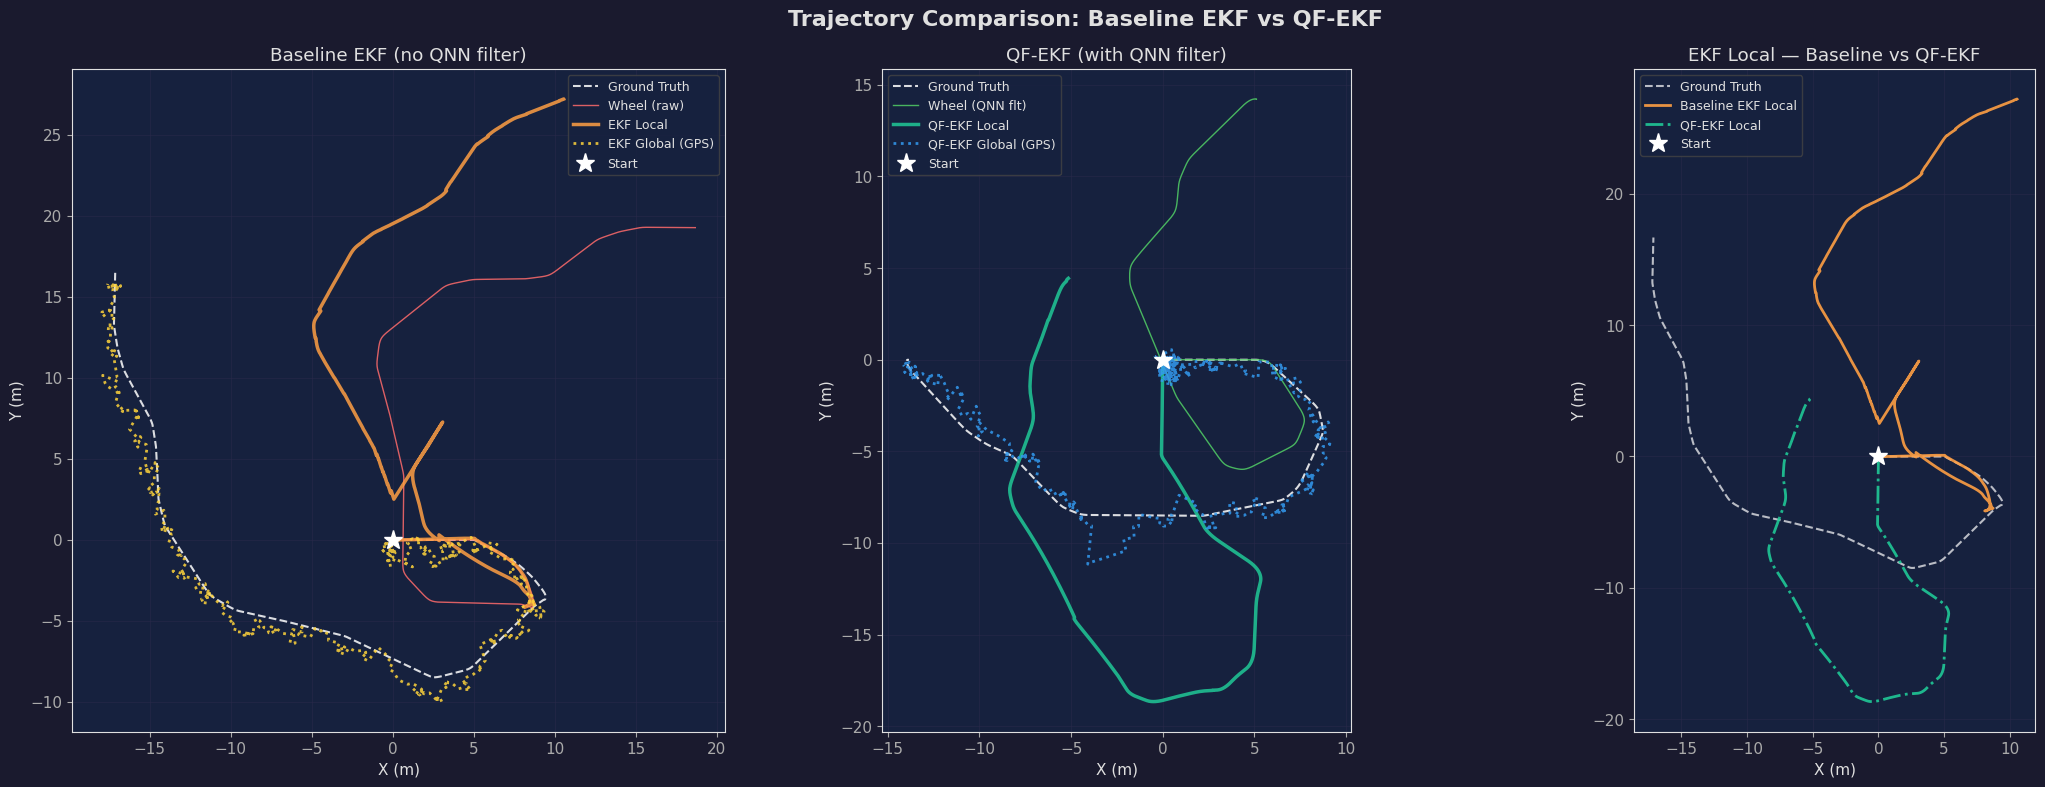


Closure errors:
                Source    Closure error
──────────────────────────────────────────
    Baseline EKF Local          29.2052 m
   Baseline EKF Global          24.1518 m
 Baseline Ground Truth          23.8934 m
          QF-EKF Local           6.7982 m
         QF-EKF Global          13.7379 m
   QF-EKF Ground Truth          13.8461 m


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Trajectory Comparison: Baseline EKF vs QF-EKF', fontsize=16, fontweight='bold')

# Left: Baseline
ax = axes[0]; ax.set_title('Baseline EKF (no QNN filter)')
for k, label, color, lw, ls in [
    ('ground_truth', 'Ground Truth',    '#ffffff',    1.5, '--'),
    ('wheel',        'Wheel (raw)',      C['b_wheel'], 1.0, '-'),
    ('ekf_local',    'EKF Local',        C['b_ekf_l'], 2.5, '-'),
    ('ekf_global',   'EKF Global (GPS)', C['b_ekf_g'], 2.0, ':'),
]:
    if k not in B: continue
    x = npc(B[k],'x'); y = npc(B[k],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=color, lw=lw, ls=ls, label=label, alpha=0.85)
ax.plot(0,0,'w*',ms=14,zorder=10,label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

# Middle: QF-EKF
ax = axes[1]; ax.set_title('QF-EKF (with QNN filter)')
for k, label, color, lw, ls in [
    ('ground_truth', 'Ground Truth',         '#ffffff',    1.5, '--'),
    ('wheel_flt',    'Wheel (QNN flt)',       C['q_wheel'], 1.0, '-'),
    ('ekf_local',    'QF-EKF Local',          C['q_ekf_l'], 2.5, '-'),
    ('ekf_global',   'QF-EKF Global (GPS)',   C['q_ekf_g'], 2.0, ':'),
]:
    if k not in Q: continue
    x = npc(Q[k],'x'); y = npc(Q[k],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=color, lw=lw, ls=ls, label=label, alpha=0.85)
ax.plot(0,0,'w*',ms=14,zorder=10,label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

# Right: EKF Local overlay (direct comparison) + ground truth
ax = axes[2]; ax.set_title('EKF Local — Baseline vs QF-EKF')
if 'ground_truth' in B:
    x = npc(B['ground_truth'],'x'); y = npc(B['ground_truth'],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color='white', lw=1.5, ls='--', label='Ground Truth', alpha=0.7)
elif 'ground_truth' in Q:
    x = npc(Q['ground_truth'],'x'); y = npc(Q['ground_truth'],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color='white', lw=1.5, ls='--', label='Ground Truth', alpha=0.7)
if 'ekf_local' in B:
    x = npc(B['ekf_local'],'x'); y = npc(B['ekf_local'],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=C['b_ekf_l'], lw=2, label='Baseline EKF Local', alpha=0.9)
if 'ekf_local' in Q:
    x = npc(Q['ekf_local'],'x'); y = npc(Q['ekf_local'],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=C['q_ekf_l'], lw=2, ls='-.', label='QF-EKF Local', alpha=0.9)
ax.plot(0,0,'w*',ms=14,zorder=10,label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/01_trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClosure errors:')
print(f'{"Source":>22}  {"Closure error":>15}')
print('─' * 42)
for label, dfs, k in [
    ('Baseline EKF Local',  B, 'ekf_local'),
    ('Baseline EKF Global', B, 'ekf_global'),
    ('Baseline Ground Truth', B, 'ground_truth'),
    ('QF-EKF Local',        Q, 'ekf_local'),
    ('QF-EKF Global',       Q, 'ekf_global'),
    ('QF-EKF Ground Truth', Q, 'ground_truth'),
]:
    if k not in dfs: continue
    x = npc(dfs[k],'x'); y = npc(dfs[k],'y'); m = mask_finite(x,y)
    if m.sum() < 2: continue
    err = np.sqrt((x[m][-1]-x[m][0])**2 + (y[m][-1]-y[m][0])**2)
    print(f'{label:>22}  {err:15.4f} m')

## 3. Drift Comparison — Baseline EKF vs QF-EKF

Baseline reference: EKF Global vs Gazebo Ground Truth
QF-EKF  reference: EKF Global vs Gazebo Ground Truth


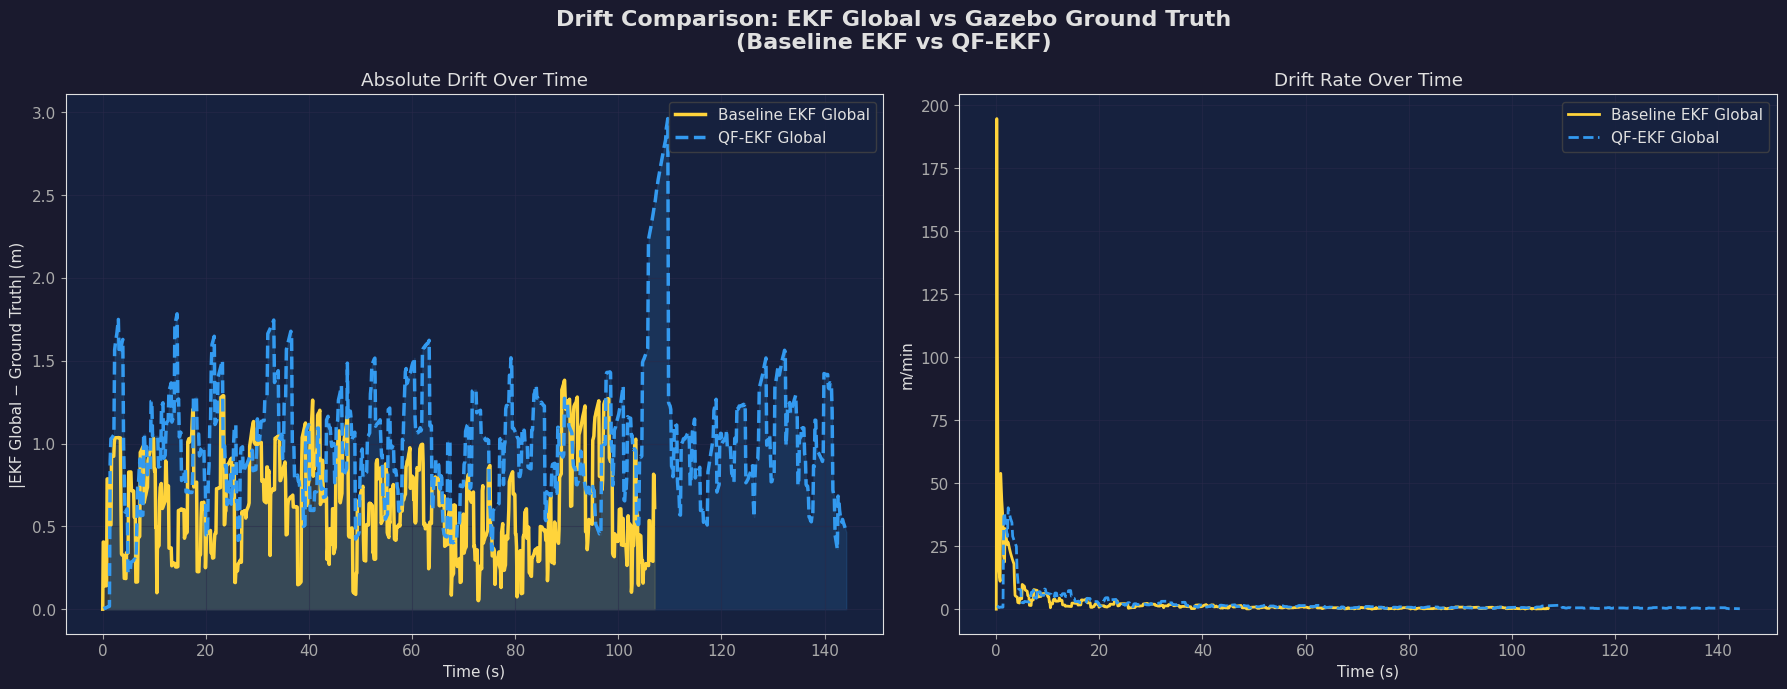


Drift Summary  (EKF Global vs Gazebo Ground Truth):
                  Final (m)    Max (m)    Rate (m/min)
────────────────────────────────────────────────────────
   Baseline EKF      0.6139     1.3823          0.3442
         QF-EKF      0.4662     2.9618          0.1942

QF-EKF improvement: -298.5%  ✗
→ QF-EKF underperforms — check RQNN filter + EKF#3 config


In [36]:
def compute_drift(dfs, label=''):
    """Drift = |ekf_global − ground_truth| (the GPS-corrected final output vs true pose)."""
    if 'ekf_global' not in dfs:
        print(f'  [{label}] no ekf_global — skipping drift')
        return None, None, None, None
    if 'ground_truth' not in dfs:
        print(f'  [{label}] no ground_truth — re-record bag after URDF rebuild')
        return None, None, None, None

    ref_label = 'Gazebo Ground Truth'
    tg = npc(dfs['ekf_global'],'t');   xg = npc(dfs['ekf_global'],'x');   yg = npc(dfs['ekf_global'],'y')
    tr = npc(dfs['ground_truth'],'t'); xr = npc(dfs['ground_truth'],'x'); yr = npc(dfs['ground_truth'],'y')
    mg = mask_finite(tg,xg,yg); mr = mask_finite(tr,xr,yr)
    if mg.sum() < 2 or mr.sum() < 2: return None, None, None, None

    t_c = np.linspace(max(tg[mg][0], tr[mr][0]), min(tg[mg][-1], tr[mr][-1]), 1000)
    gx = np.interp(t_c, tg[mg], xg[mg]) - xg[mg][0]
    gy = np.interp(t_c, tg[mg], yg[mg]) - yg[mg][0]
    rx = np.interp(t_c, tr[mr], xr[mr]) - xr[mr][0]
    ry = np.interp(t_c, tr[mr], yr[mr]) - yr[mr][0]
    drift = np.sqrt((gx - rx)**2 + (gy - ry)**2)
    return t_c, drift, 'ekf_global', ref_label

t_b, drift_b, ref_b_key, ref_b_label = compute_drift(B, 'Baseline')
t_q, drift_q, ref_q_key, ref_q_label = compute_drift(Q, 'QF-EKF')

print(f'Baseline reference: EKF Global vs {ref_b_label}' if t_b is not None else 'Baseline: no data')
print(f'QF-EKF  reference: EKF Global vs {ref_q_label}' if t_q is not None else 'QF-EKF: no data')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Drift Comparison: EKF Global vs Gazebo Ground Truth\n(Baseline EKF vs QF-EKF)',
             fontsize=16, fontweight='bold')

ax = axes[0]
if t_b is not None:
    ax.plot(t_b, drift_b, color=C['b_ekf_g'], lw=2.5, label='Baseline EKF Global')
    ax.fill_between(t_b, 0, drift_b, color=C['b_ekf_g'], alpha=0.15)
if t_q is not None:
    ax.plot(t_q, drift_q, color=C['q_ekf_g'], lw=2.5, ls='--', label='QF-EKF Global')
    ax.fill_between(t_q, 0, drift_q, color=C['q_ekf_g'], alpha=0.15)
ax.set_xlabel('Time (s)'); ax.set_ylabel('|EKF Global − Ground Truth| (m)')
ax.set_title('Absolute Drift Over Time'); ax.legend(); ax.grid(True)

ax2 = axes[1]
if t_b is not None:
    ax2.plot(t_b, drift_b / (t_b + 1e-6) * 60, color=C['b_ekf_g'], lw=2, label='Baseline EKF Global')
if t_q is not None:
    ax2.plot(t_q, drift_q / (t_q + 1e-6) * 60, color=C['q_ekf_g'], lw=2, ls='--', label='QF-EKF Global')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('m/min')
ax2.set_title('Drift Rate Over Time'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_drift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDrift Summary  (EKF Global vs Gazebo Ground Truth):')
print(f'{"":>15}  {"Final (m)":>10}  {"Max (m)":>9}  {"Rate (m/min)":>14}')
print('─' * 56)
for label, t_c, drift in [('Baseline EKF', t_b, drift_b), ('QF-EKF', t_q, drift_q)]:
    if t_c is None: continue
    dur = t_c[-1] - t_c[0]
    print(f'{label:>15}  {drift[-1]:10.4f}  {drift.max():9.4f}  {drift[-1]/dur*60:14.4f}')

if t_b is not None and t_q is not None:
    t_common = np.linspace(max(t_b[0], t_q[0]), min(t_b[-1], t_q[-1]), 500)
    db = np.interp(t_common, t_b, drift_b)
    dq = np.interp(t_common, t_q, drift_q)
    improvement = (1 - dq[-1] / db[-1]) * 100 if db[-1] > 0 else 0
    sign = '✓' if improvement > 0 else '✗'
    print(f'\nQF-EKF improvement: {improvement:.1f}%  {sign}')
    if improvement <= 0:
        print('→ QF-EKF underperforms — check RQNN filter + EKF#3 config')

## 4. Velocity Tracking — Baseline vs QF-EKF

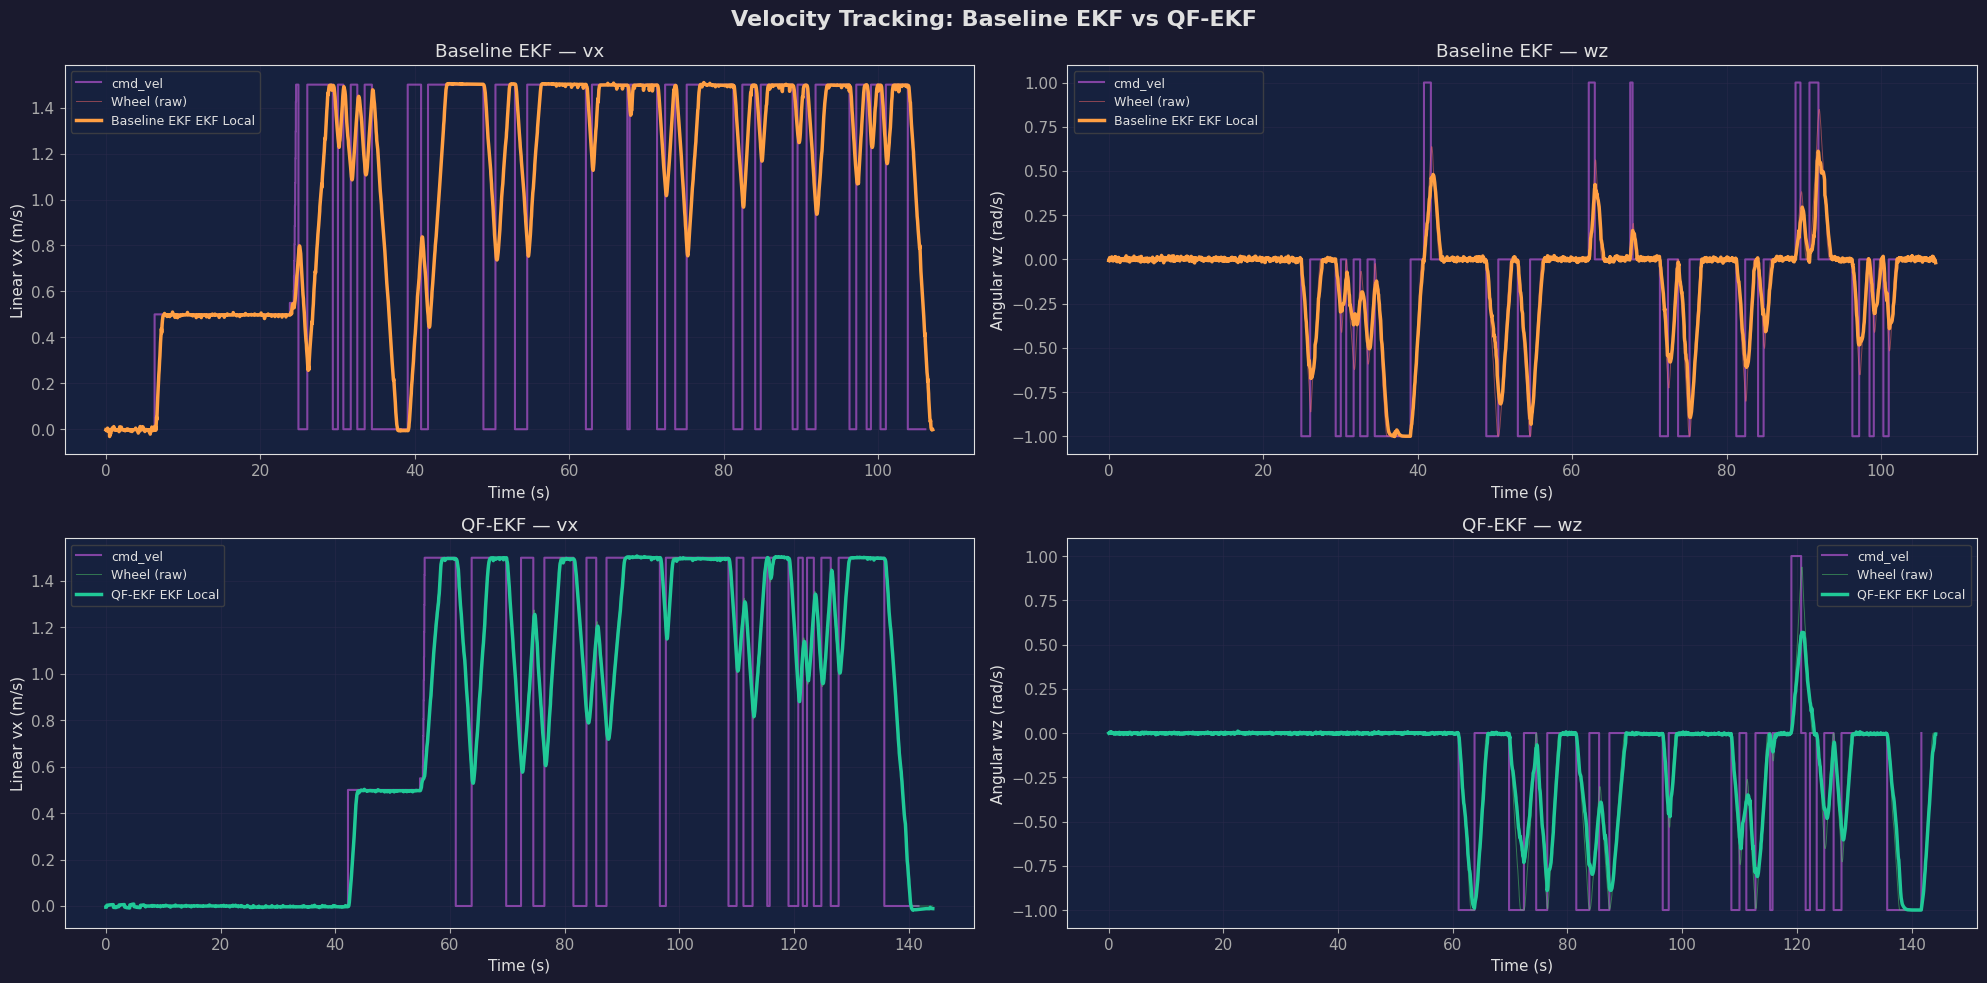


Velocity RMSE vs cmd_vel:
                    vx RMSE     wz RMSE
────────────────────────────────────────
   Baseline EKF      0.5866      0.3527
         QF-EKF      0.5980      0.3827


In [43]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.suptitle('Velocity Tracking: Baseline EKF vs QF-EKF', fontsize=16, fontweight='bold')

for col_i, (col, ylabel) in enumerate([('vx','Linear vx (m/s)'), ('wz','Angular wz (rad/s)')]):
    for row, (label, dfs, clr_ekf, clr_raw) in enumerate([
        ('Baseline EKF', B, C['b_ekf_l'], C['b_wheel']),
        ('QF-EKF',       Q, C['q_ekf_l'], C['q_wheel']),
    ]):
        ax = axes[row, col_i]
        cmd_k = 'cmd_vel'
        if cmd_k in dfs:
            t = npc(dfs[cmd_k],'t'); v = npc(dfs[cmd_k], col)
            m = mask_finite(t, v)
            ax.step(t[m], v[m], color=C['cmd_vel'], lw=1.5, where='post',
                    alpha=0.6, label='cmd_vel')
        if 'wheel' in dfs:
            t = npc(dfs['wheel'],'t'); v = npc(dfs['wheel'], col)
            m = mask_finite(t, v)
            ax.plot(t[m], v[m], color=clr_raw, lw=0.7, alpha=0.5, label='Wheel (raw)')
        if 'ekf_local' in dfs:
            t = npc(dfs['ekf_local'],'t'); v = npc(dfs['ekf_local'], col)
            m = mask_finite(t, v)
            ax.plot(t[m], v[m], color=clr_ekf, lw=2.5, label=f'{label} EKF Local')
        ax.set_ylabel(ylabel); ax.set_xlabel('Time (s)')
        ax.set_title(f'{label} — {col}'); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_velocity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nVelocity RMSE vs cmd_vel:')
print(f'{"":>15}  {"vx RMSE":>10}  {"wz RMSE":>10}')
print('─' * 40)
for label, dfs in [('Baseline EKF', B), ('QF-EKF', Q)]:
    if 'cmd_vel' not in dfs or 'ekf_local' not in dfs: continue
    tc = npc(dfs['cmd_vel'],'t')
    rmse_vals = []
    for col in ['vx', 'wz']:
        vc = npc(dfs['cmd_vel'], col); mc = mask_finite(tc, vc)
        te = npc(dfs['ekf_local'],'t'); ve = npc(dfs['ekf_local'], col)
        me = mask_finite(te, ve)
        ve_i = np.interp(tc[mc], te[me], ve[me])
        rmse_vals.append(np.sqrt(np.mean((vc[mc]-ve_i)**2)))
    print(f'{label:>15}  {rmse_vals[0]:10.4f}  {rmse_vals[1]:10.4f}')

## 5. IMU Noise — Raw vs QNN Filtered

   Channel      Raw σ      QNN σ   Noise reduc%   SNR gain dB
────────────────────────────────────────────────────────────
    Gyro Z    0.01242    0.01031          17.0%          1.61 dB
    Gyro X    0.00887    0.00000         100.0%         76.17 dB
    Gyro Y    0.00867    0.00000         100.0%         69.75 dB
   Accel X    0.29258    0.08890          69.6%         10.35 dB
   Accel Y    0.27256    0.10964          59.8%          7.91 dB
   Accel Z    0.05397    0.00517          90.4%         20.37 dB


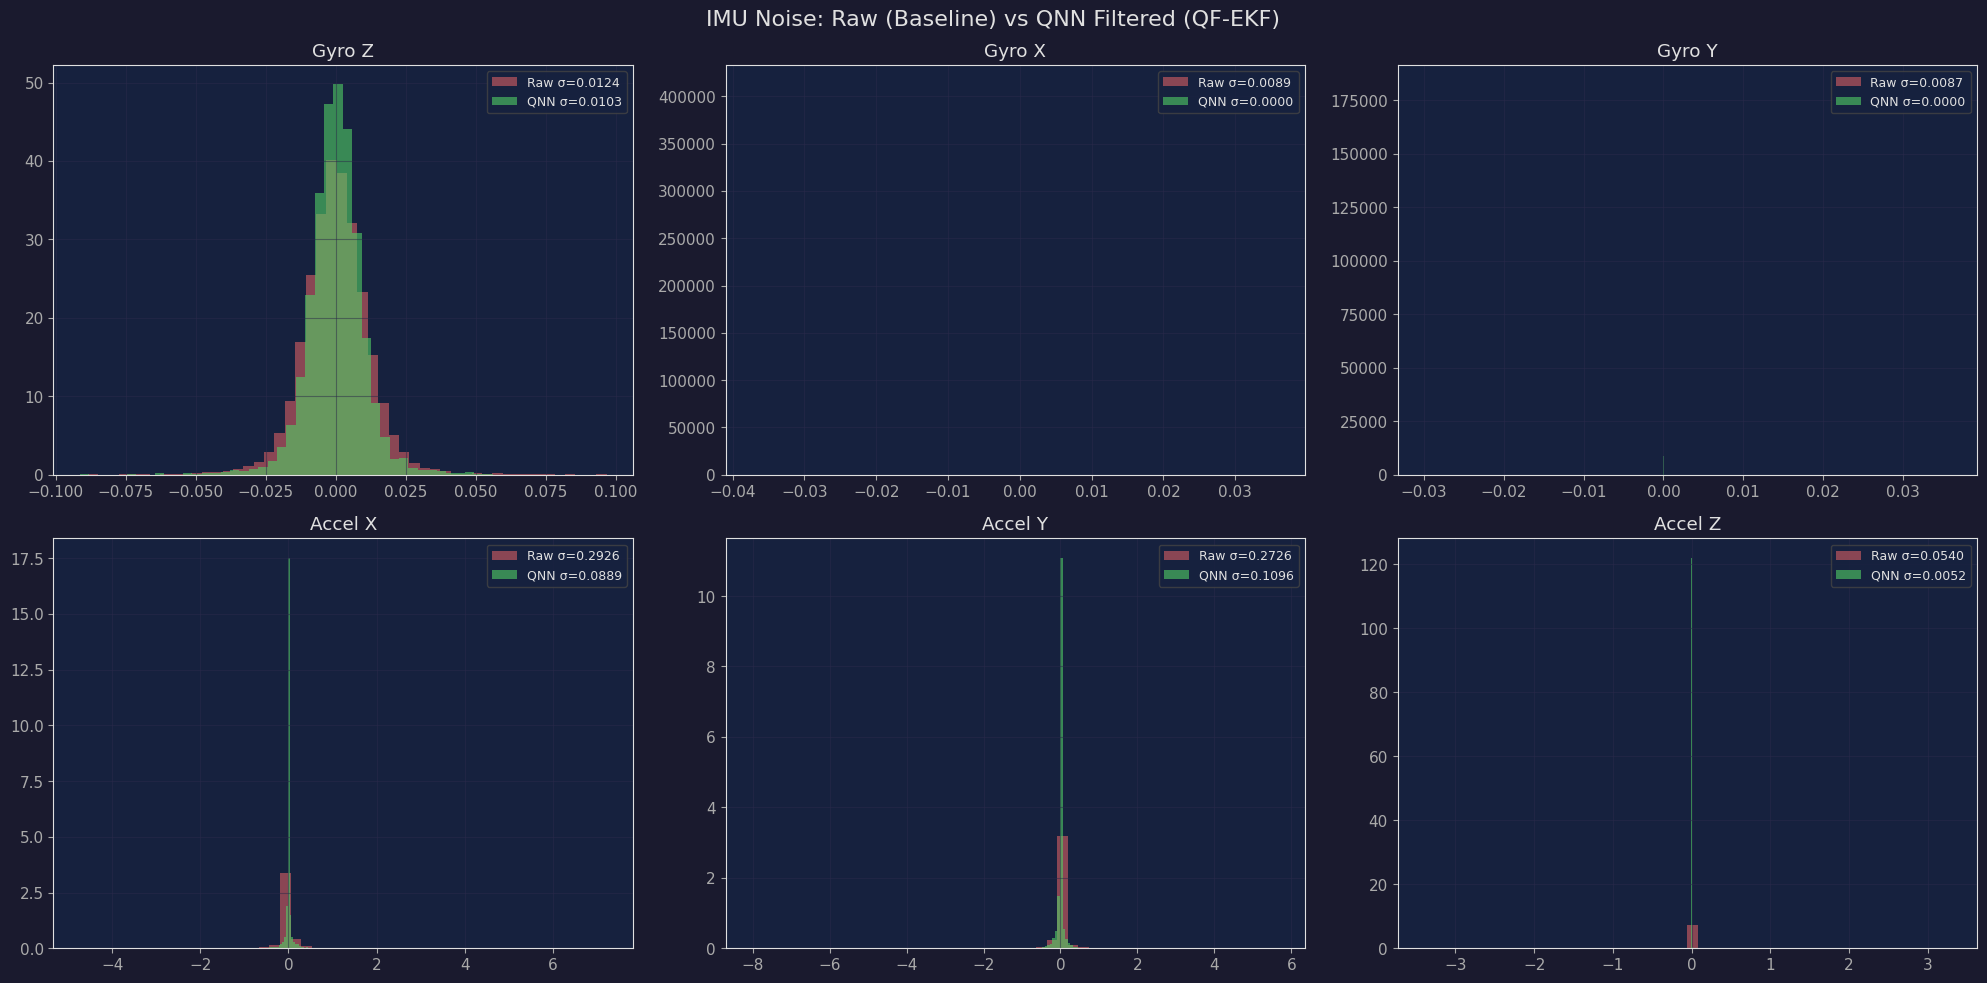

In [38]:
channels = [
    ('gz','Gyro Z'), ('gx','Gyro X'), ('gy','Gyro Y'),
    ('ax','Accel X'), ('ay','Accel Y'), ('az','Accel Z'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('IMU Noise: Raw (Baseline) vs QNN Filtered (QF-EKF)', fontsize=16)

print(f'{"Channel":>10}  {"Raw σ":>9}  {"QNN σ":>9}  {"Noise reduc%":>13}  {"SNR gain dB":>12}')
print('─' * 60)

for ax, (col, label) in zip(axes.flat, channels):
    # Raw from baseline bag
    dr, dq = None, None
    if 'imu' in B:
        d = npc(B['imu'], col); d = d[np.isfinite(d)]
        dr = d
        std_r = noise_std(dr)
        wl = min(51, max(5, (len(dr)//5)*2+1))
        if wl%2==0: wl+=1
        nr = dr - savgol_filter(dr, wl, 3)
        ax.hist(nr, bins=50, density=True, color=C['imu_raw'],
                alpha=0.5, label=f'Raw σ={std_r:.4f}')

    # Filtered from hybrid bag
    if 'imu_flt' in Q:
        d = npc(Q['imu_flt'], col); d = d[np.isfinite(d)]
        dq = d
        std_f = noise_std(dq)
        wl = min(51, max(5, (len(dq)//5)*2+1))
        if wl%2==0: wl+=1
        nf = dq - savgol_filter(dq, wl, 3)
        ax.hist(nf, bins=50, density=True, color=C['imu_flt'],
                alpha=0.6, label=f'QNN σ={std_f:.4f}')

        if dr is not None:
            red = (1 - std_f/std_r)*100 if std_r > 0 else 0
            snr = 20*np.log10(std_r/std_f) if std_f > 0 else 0
            print(f'{label:>10}  {std_r:9.5f}  {std_f:9.5f}  {red:12.1f}%  {snr:12.2f} dB')

    ax.set_title(label); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/04_imu_noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. GPS Innovation Comparison

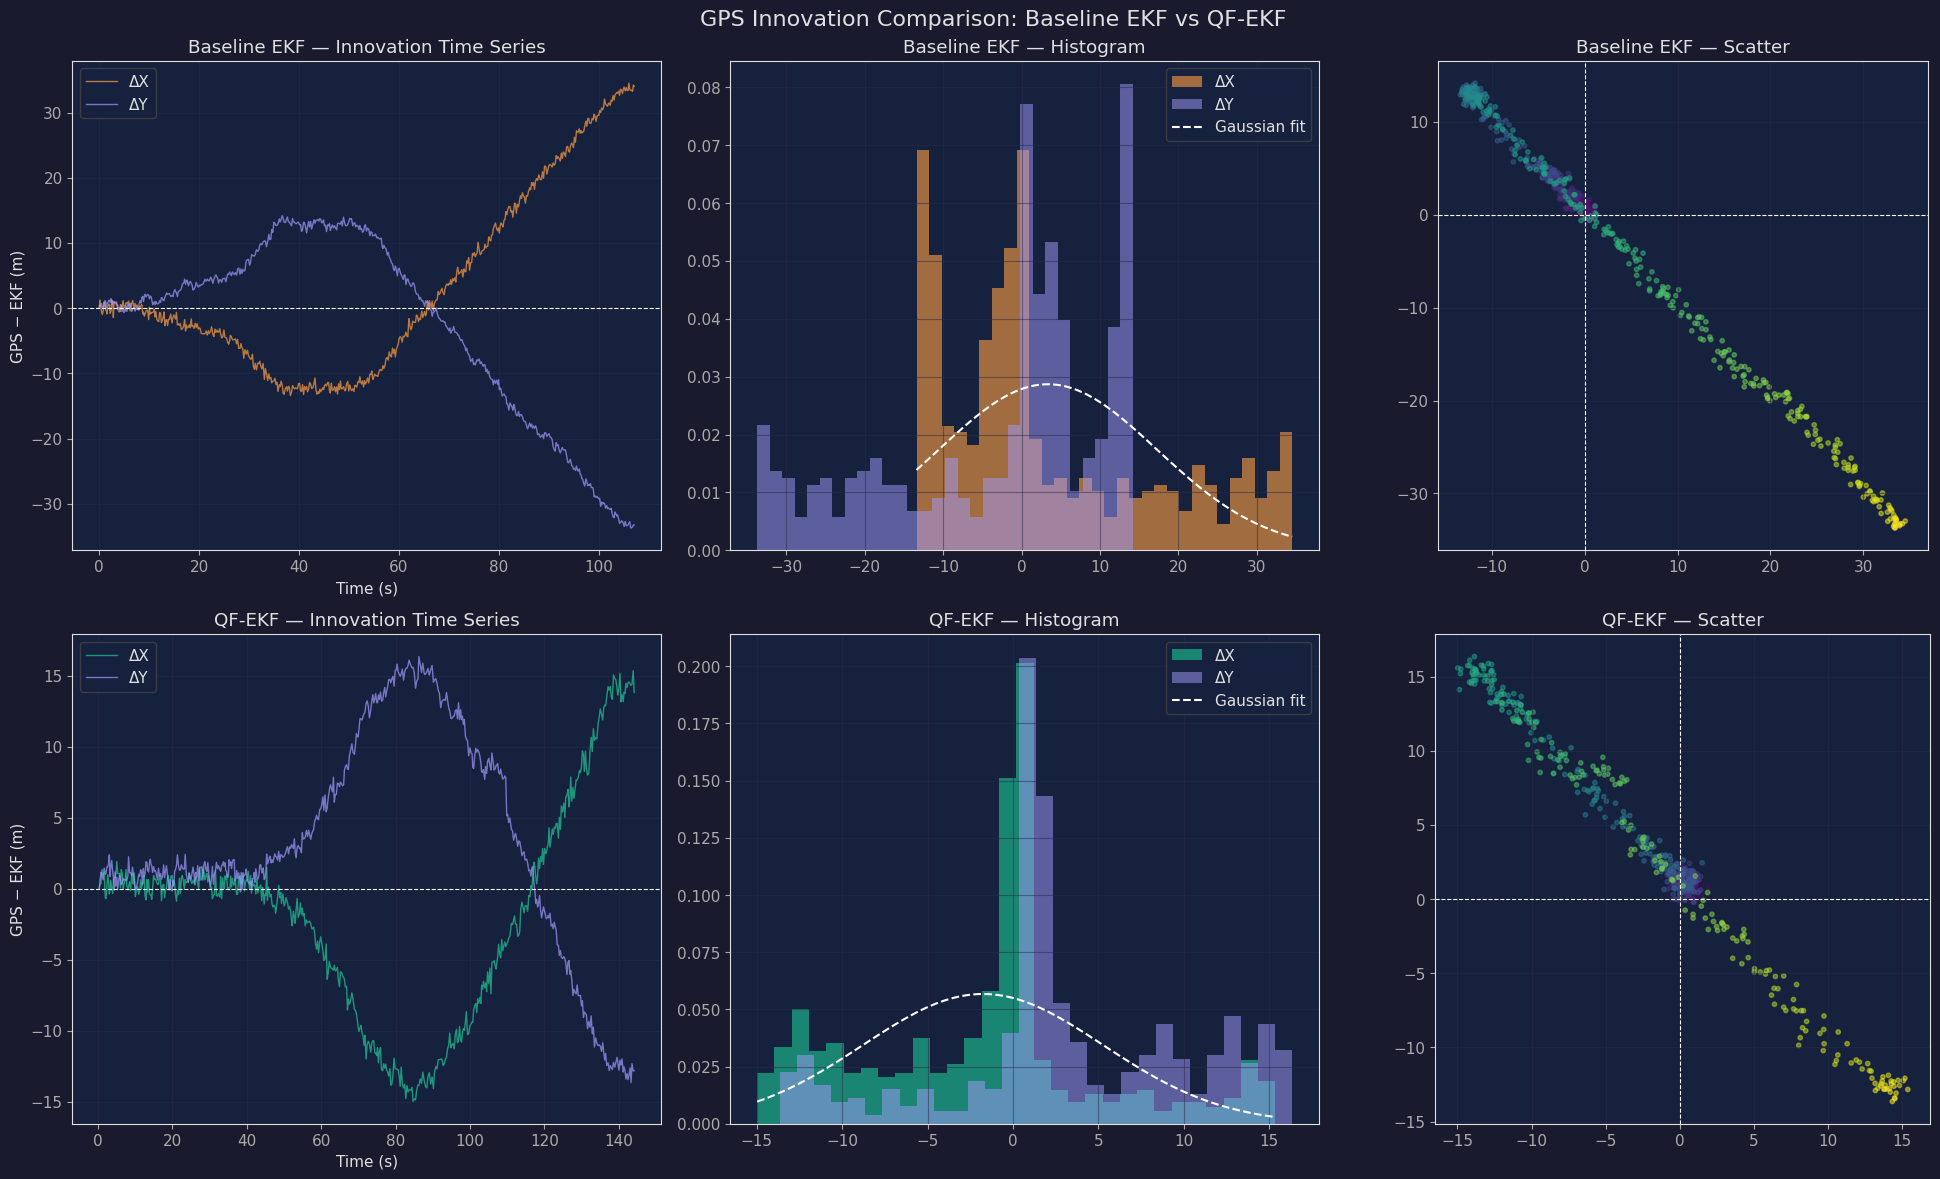


GPS Innovation Statistics:
                   ΔX mean    ΔX std    ΔY mean    ΔY std    2D RMSE
─────────────────────────────────────────────────────────────────
   Baseline EKF     3.3598   13.9063    -2.7674   13.8270    20.0878
         QF-EKF    -1.7548    7.0334     3.1489    7.2271    10.7095

GPS RMSE improvement: 46.7%


In [39]:
def compute_innovation(dfs):
    if 'gps' not in dfs or 'ekf_global' not in dfs:
        return None, None, None
    gps = dfs['gps']; ekf = dfs['ekf_global']
    lat = npc(gps,'lat'); lon = npc(gps,'lon')
    lat_m = (lat - lat[0]) * 111320
    lon_m = (lon - lon[0]) * 111320 * np.cos(np.radians(lat[0]))
    tg = npc(gps,'t'); te = npc(ekf,'t')
    xe = npc(ekf,'x'); ye = npc(ekf,'y')
    me = mask_finite(te, xe, ye)
    lat_m += xe[me][0] - lat_m[0]; lon_m += ye[me][0] - lon_m[0]
    mg = mask_finite(tg, lat_m, lon_m)
    ix = lat_m[mg] - np.interp(tg[mg], te[me], xe[me])
    iy = lon_m[mg] - np.interp(tg[mg], te[me], ye[me])
    return tg[mg], ix, iy

t_b_i, ix_b, iy_b = compute_innovation(B)
t_q_i, ix_q, iy_q = compute_innovation(Q)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('GPS Innovation Comparison: Baseline EKF vs QF-EKF', fontsize=16)

for row, (t_i, ix, iy, label, clr) in enumerate([
    (t_b_i, ix_b, iy_b, 'Baseline EKF', C['b_ekf_l']),
    (t_q_i, ix_q, iy_q, 'QF-EKF',       C['q_ekf_l']),
]):
    if t_i is None: continue

    axes[row,0].plot(t_i, ix, color=clr, lw=1, alpha=0.7, label='ΔX')
    axes[row,0].plot(t_i, iy, color=C['gps'], lw=1, alpha=0.7, label='ΔY')
    axes[row,0].axhline(0, color='white', ls='--', lw=0.8)
    axes[row,0].set_title(f'{label} — Innovation Time Series')
    axes[row,0].set_xlabel('Time (s)'); axes[row,0].set_ylabel('GPS − EKF (m)')
    axes[row,0].legend(); axes[row,0].grid(True)

    axes[row,1].hist(ix, bins=30, color=clr, alpha=0.6, density=True, label='ΔX')
    axes[row,1].hist(iy, bins=30, color=C['gps'], alpha=0.5, density=True, label='ΔY')
    xr = np.linspace(ix.min(), ix.max(), 100)
    axes[row,1].plot(xr, stats.norm.pdf(xr, ix.mean(), ix.std()), 'w--', lw=1.5, label='Gaussian fit')
    axes[row,1].set_title(f'{label} — Histogram'); axes[row,1].legend(); axes[row,1].grid(True)

    axes[row,2].scatter(ix, iy, c=t_i, cmap='viridis', s=10, alpha=0.5)
    axes[row,2].axhline(0, color='white', ls='--', lw=0.8)
    axes[row,2].axvline(0, color='white', ls='--', lw=0.8)
    axes[row,2].set_title(f'{label} — Scatter')
    axes[row,2].set_aspect('equal'); axes[row,2].grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_innovation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGPS Innovation Statistics:')
print(f'{"":>15}  {"ΔX mean":>9}  {"ΔX std":>8}  {"ΔY mean":>9}  {"ΔY std":>8}  {"2D RMSE":>9}')
print('─' * 65)
for label, ix, iy in [('Baseline EKF', ix_b, iy_b), ('QF-EKF', ix_q, iy_q)]:
    if ix is None: continue
    rmse = np.sqrt(np.mean(ix**2 + iy**2))
    print(f'{label:>15}  {ix.mean():9.4f}  {ix.std():8.4f}  {iy.mean():9.4f}  {iy.std():8.4f}  {rmse:9.4f}')

if ix_b is not None and ix_q is not None:
    rmse_b = np.sqrt(np.mean(ix_b**2 + iy_b**2))
    rmse_q = np.sqrt(np.mean(ix_q**2 + iy_q**2))
    print(f'\nGPS RMSE improvement: {(1 - rmse_q/rmse_b)*100:.1f}%')

## 7. Yaw Accuracy Comparison

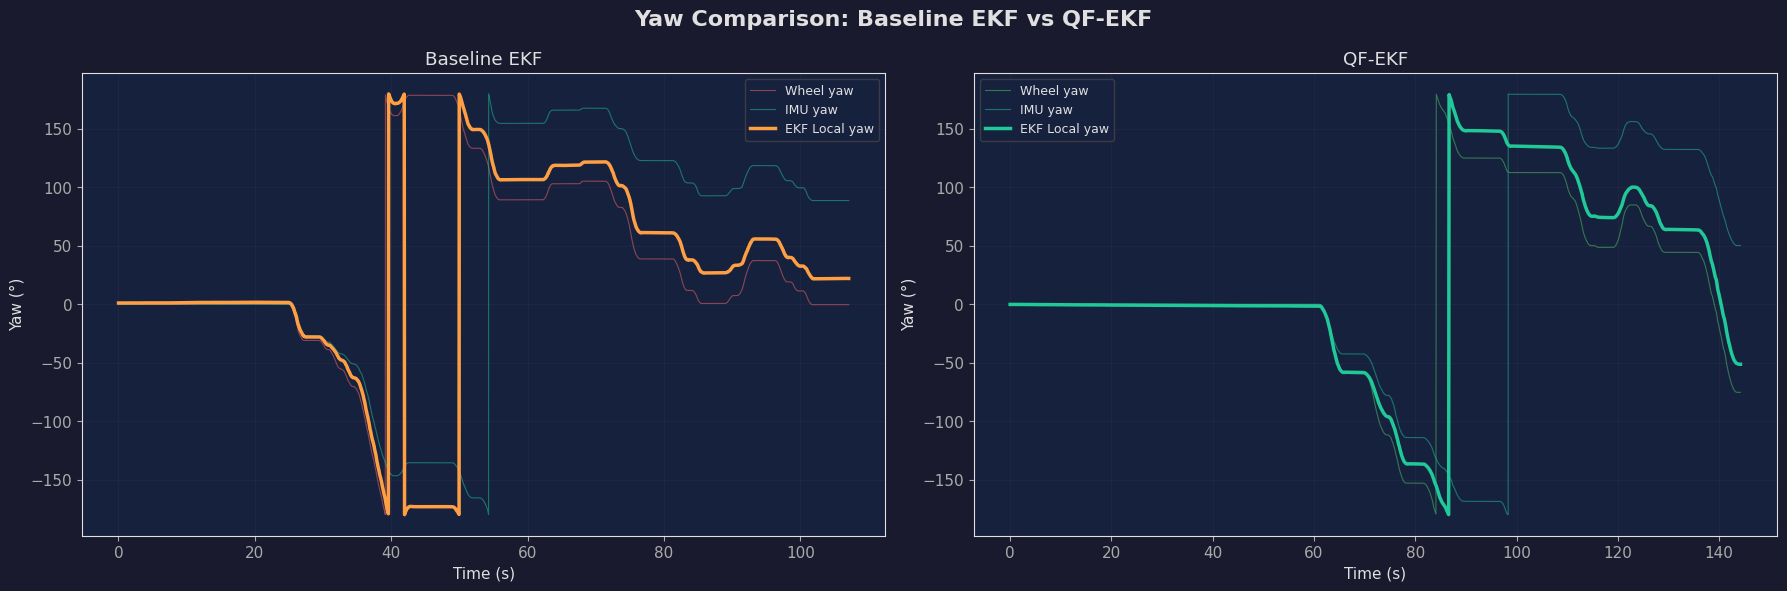

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Yaw Comparison: Baseline EKF vs QF-EKF', fontsize=16, fontweight='bold')

for ax, (label, dfs, c_ekf, c_wheel) in zip(axes, [
    ('Baseline EKF', B, C['b_ekf_l'], C['b_wheel']),
    ('QF-EKF',       Q, C['q_ekf_l'], C['q_wheel']),
]):
    if 'wheel' in dfs:
        t = npc(dfs['wheel'],'t'); y = np.degrees(npc(dfs['wheel'],'yaw'))
        m = mask_finite(t,y)
        ax.plot(t[m], y[m], color=c_wheel, lw=0.8, alpha=0.5, label='Wheel yaw')
    if 'imu' in dfs:
        t = npc(dfs['imu'],'t'); y = np.degrees(npc(dfs['imu'],'yaw'))
        m = mask_finite(t,y)
        ax.plot(t[m], y[m], color='#20c997', lw=0.8, alpha=0.5, label='IMU yaw')
    if 'ekf_local' in dfs:
        t = npc(dfs['ekf_local'],'t'); y = np.degrees(npc(dfs['ekf_local'],'yaw'))
        m = mask_finite(t,y)
        ax.plot(t[m], y[m], color=c_ekf, lw=2.5, label='EKF Local yaw')
    ax.set_title(label); ax.set_xlabel('Time (s)'); ax.set_ylabel('Yaw (°)')
    ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/06_yaw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. EKF Covariance Comparison

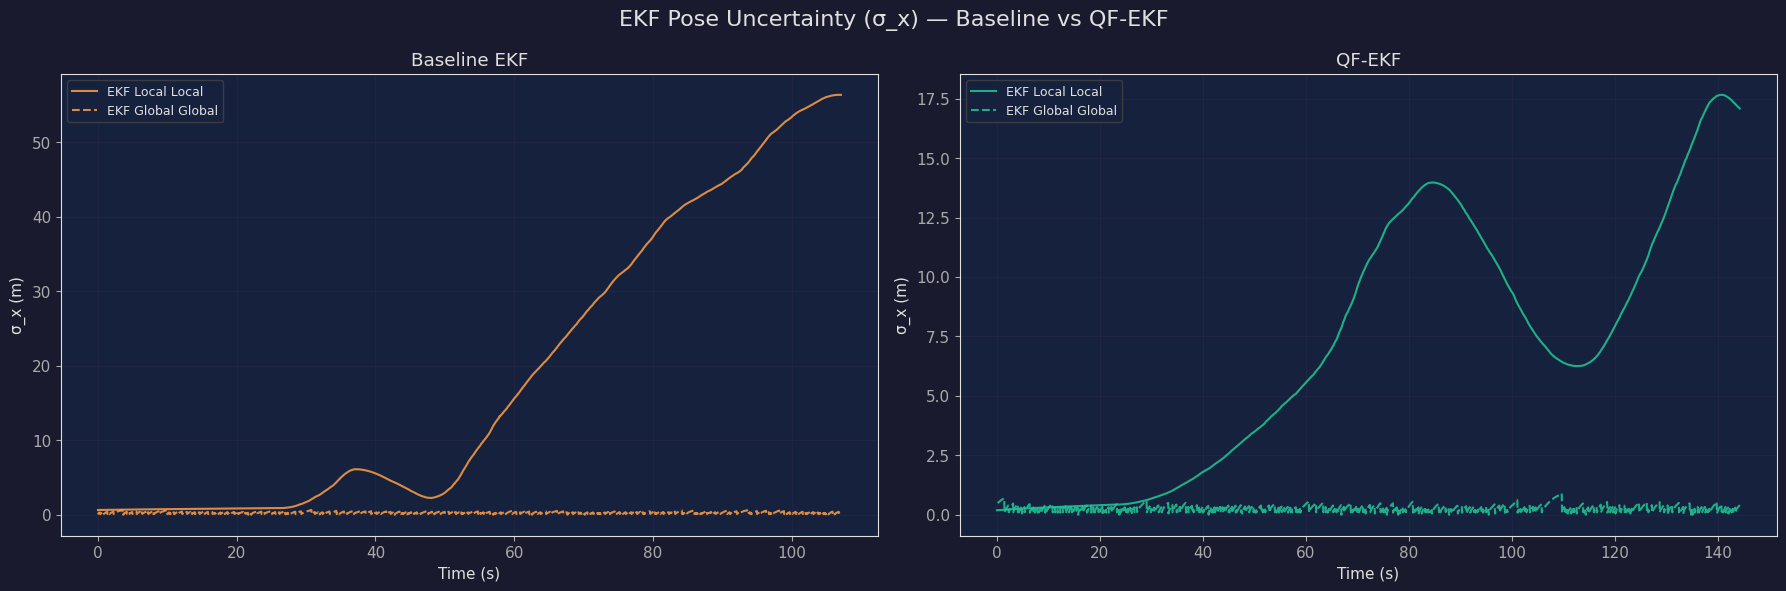

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EKF Pose Uncertainty (σ_x) — Baseline vs QF-EKF', fontsize=16)

for k, label in [('ekf_local', 'EKF Local'), ('ekf_global', 'EKF Global')]:
    for ax, (dfs, name, c) in zip(axes, [
        (B, 'Baseline', C['b_ekf_l']),
        (Q, 'QF-EKF',   C['q_ekf_l']),
    ]):
        if k not in dfs: continue
        t = npc(dfs[k],'t'); sx = np.sqrt(np.abs(npc(dfs[k],'cov_xx')))
        m = mask_finite(t, sx)
        ls = '-' if k == 'ekf_local' else '--'
        ax.plot(t[m], sx[m], color=c, lw=1.5, ls=ls,
                label=f'{label} {k.replace("ekf_","").title()}', alpha=0.85)

for ax, name in zip(axes, ['Baseline EKF', 'QF-EKF']):
    ax.set_title(name); ax.set_xlabel('Time (s)'); ax.set_ylabel('σ_x (m)')
    ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/07_covariance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Quantitative Comparison Table

In [42]:
print('=' * 80)
print('QUANTITATIVE COMPARISON: BASELINE EKF vs QF-EKF')
print('Drift metric: |EKF Global − Gazebo Ground Truth|')
print('=' * 80)

# ── Drift ──
print('\n[DRIFT  (EKF Global vs Ground Truth)]')
print(f'{"":>15}  {"Final (m)":>10}  {"Max (m)":>9}  {"Rate (m/min)":>14}')
print('─' * 56)
for label, t_c, drift in [('Baseline EKF', t_b, drift_b), ('QF-EKF', t_q, drift_q)]:
    if t_c is None:
        print(f'{label:>15}  no ground_truth in bag — re-record')
        continue
    dur = t_c[-1] - t_c[0]
    print(f'{label:>15}  {drift[-1]:10.4f}  {drift.max():9.4f}  {drift[-1]/dur*60:14.4f}')

if t_b is not None and t_q is not None:
    t_common = np.linspace(max(t_b[0], t_q[0]), min(t_b[-1], t_q[-1]), 500)
    db = np.interp(t_common, t_b, drift_b)
    dq = np.interp(t_common, t_q, drift_q)
    improvement = (1 - dq[-1] / db[-1]) * 100 if db[-1] > 0 else 0
    sign = '✓' if improvement > 0 else '✗'
    print(f'\n  QF-EKF drift improvement: {improvement:.1f}%  {sign}')

# ── IMU Noise ──
print('\n[IMU NOISE REDUCTION (QNN filter)]')
print(f'{"Channel":>10}  {"Baseline σ":>11}  {"QF-EKF σ":>10}  {"Reduction%":>12}  {"SNR gain dB":>13}')
print('─' * 62)
for col, label in [('gz','Gyro Z'), ('gx','Gyro X'), ('gy','Gyro Y'),
                   ('ax','Accel X'), ('ay','Accel Y')]:
    sr = noise_std(npc(B['imu'],col)[np.isfinite(npc(B['imu'],col))]) if 'imu' in B else None
    sf = noise_std(npc(Q['imu_flt'],col)[np.isfinite(npc(Q['imu_flt'],col))]) if 'imu_flt' in Q else None
    if sr and sf:
        red = (1 - sf/sr) * 100
        snr = 20*np.log10(sr/sf) if sf > 0 else 0
        print(f'{label:>10}  {sr:11.5f}  {sf:10.5f}  {red:11.1f}%  {snr:12.2f} dB')

# ── GPS Innovation ──
print('\n[GPS INNOVATION RMSE]')
if ix_b is not None: print(f'  Baseline EKF : {np.sqrt(np.mean(ix_b**2+iy_b**2)):.4f} m')
if ix_q is not None: print(f'  QF-EKF       : {np.sqrt(np.mean(ix_q**2+iy_q**2)):.4f} m')

# ── Velocity RMSE ──
print('\n[VELOCITY RMSE vs cmd_vel]')
print(f'{"":>15}  {"vx RMSE":>10}  {"wz RMSE":>10}')
print('─' * 40)
for label, dfs in [('Baseline EKF', B), ('QF-EKF', Q)]:
    if 'cmd_vel' not in dfs or 'ekf_global' not in dfs: continue
    tc = npc(dfs['cmd_vel'],'t')
    rmse_vals = []
    for col in ['vx', 'wz']:
        vc = npc(dfs['cmd_vel'], col); mc = mask_finite(tc, vc)
        te = npc(dfs['ekf_global'],'t'); ve = npc(dfs['ekf_global'], col)
        me = mask_finite(te, ve)
        ve_i = np.interp(tc[mc], te[me], ve[me])
        rmse_vals.append(np.sqrt(np.mean((vc[mc]-ve_i)**2)))
    print(f'{label:>15}  {rmse_vals[0]:10.4f}  {rmse_vals[1]:10.4f}')

# ── Closure Error on EKF Global ──
print('\n[CLOSURE ERROR (EKF Global)]')
for label, dfs in [('Baseline EKF', B), ('QF-EKF', Q)]:
    if 'ekf_global' not in dfs: continue
    x = npc(dfs['ekf_global'],'x'); y = npc(dfs['ekf_global'],'y'); m = mask_finite(x,y)
    if m.sum() > 1:
        err = np.sqrt((x[m][-1]-x[m][0])**2 + (y[m][-1]-y[m][0])**2)
        print(f'  {label}: {err:.4f} m')

print('\n' + '=' * 80)

QUANTITATIVE COMPARISON: BASELINE EKF vs QF-EKF
Drift metric: |EKF Global − Gazebo Ground Truth|

[DRIFT  (EKF Global vs Ground Truth)]
                  Final (m)    Max (m)    Rate (m/min)
────────────────────────────────────────────────────────
   Baseline EKF      0.6139     1.3823          0.3442
         QF-EKF      0.4662     2.9618          0.1942

  QF-EKF drift improvement: -298.5%  ✗

[IMU NOISE REDUCTION (QNN filter)]
   Channel   Baseline σ    QF-EKF σ    Reduction%    SNR gain dB
──────────────────────────────────────────────────────────────
    Gyro Z      0.01242     0.01031         17.0%          1.61 dB
    Gyro X      0.00887     0.00000        100.0%         76.17 dB
    Gyro Y      0.00867     0.00000        100.0%         69.75 dB
   Accel X      0.29258     0.08890         69.6%         10.35 dB
   Accel Y      0.27256     0.10964         59.8%          7.91 dB

[GPS INNOVATION RMSE]
  Baseline EKF : 20.0878 m
  QF-EKF       : 10.7095 m

[VELOCITY RMSE vs cmd_vel